In [ ]:
# Q3: Feature Engineering and Regression Pipeline

This notebook builds a regression model to predict the number of items sold using feature engineering and a machine learning pipeline.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [4]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (1200, 9)

Data types:
 transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type         object
is_weekend              int64
is_festival             int64
competition_density     int64
items_sold              int64
dtype: object

Missing values:
 transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64


In [5]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [6]:
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [ ]:
## Date Feature Engineering

New features were extracted from the transaction_date column, including year, month, and day of the week.

An additional binary feature, is_month_end, was created to indicate whether a transaction occurred towards the end of the month.

These features help capture temporal patterns in sales behaviour.

In [7]:
df = df.sort_values(by='transaction_date')

In [8]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


In [9]:
X_train = train_df.drop(columns=['items_sold'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold'])
y_test = test_df['items_sold']

In [ ]:
## Temporal Train-Test Split

The dataset was sorted by transaction_date to preserve the time order.

Instead of using a random split, the most recent 20% of the data was used as the test set, while the earlier 80% was used for training.

A random split is inappropriate for time-based data because it can lead to data leakage, where information from the future is used to predict the past. This would result in unrealistic model performance.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [16]:
categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [col for col in X_train.columns
                  if col not in categorical_cols + ['transaction_date']]

In [17]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [18]:
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [19]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [21]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [22]:
linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [23]:
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [24]:
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression")
print("RMSE:", round(rmse_linear, 2))
print("MAE :", round(mae_linear, 2))

print("\nRandom Forest Regressor")
print("RMSE:", round(rmse_rf, 2))
print("MAE :", round(mae_rf, 2))

Linear Regression
RMSE: 27.12
MAE : 21.05

Random Forest Regressor
RMSE: 30.84
MAE : 24.31


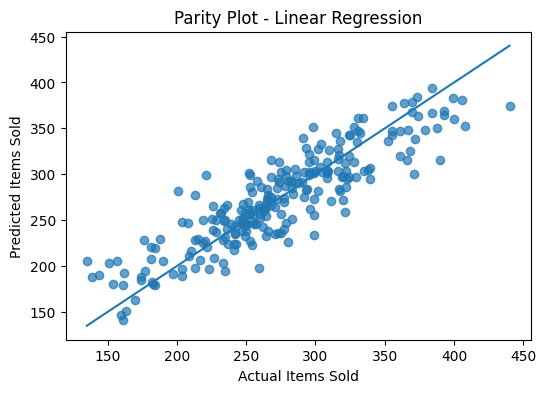

In [25]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_linear, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Parity Plot - Linear Regression')
plt.show()

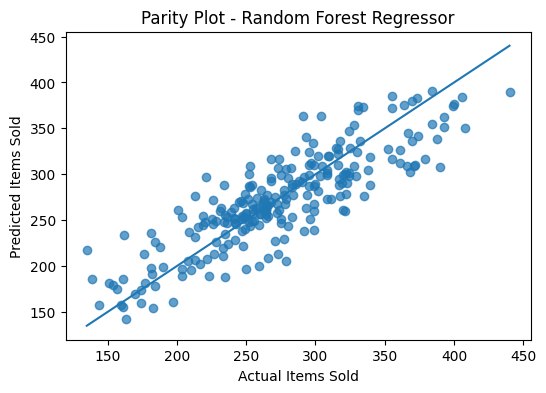

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.title('Parity Plot - Random Forest Regressor')
plt.show()

In [27]:
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
2,num__is_festival,0.173413
18,cat__store_size_small,0.166752
15,cat__location_type_urban,0.108505
6,num__day_of_week,0.080552
1,num__is_weekend,0.067103
0,num__store_id,0.054821
13,cat__location_type_rural,0.052593
3,num__competition_density,0.050869
16,cat__store_size_large,0.049790
5,num__month,0.037345


In [28]:
top_5_features = importance_df.head(5)
top_5_features

,Feature,Importance
2,num__is_festival,0.173413
18,cat__store_size_small,0.166752
15,cat__location_type_urban,0.108505
6,num__day_of_week,0.080552
1,num__is_weekend,0.067103


In [ ]:
## Model Training and Evaluation

Two regression models were trained using the preprocessing pipeline:

- Linear Regression
- Random Forest Regressor

Model performance was evaluated using RMSE and MAE on the test set. Lower values indicate better predictive performance.

Parity plots were used to compare predicted values against actual items sold. Points closer to the diagonal line indicate better predictions.

Feature importance from the Random Forest model was also extracted to identify the most influential predictors of items_sold.